In [1]:
import jax
import jax.numpy as jnp
from jax import jit, vmap
from functools import partial
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import pickle
from aux import format_plot

dt=1e-4
INPUT_START = 0.5

input_start_int = int(INPUT_START/dt)

In [2]:
def plot_results(all_results, t, n, save_path='network_training'):
    """Plot results for all networks"""
    n_networks = len(all_results)
    
    # Plot 1: Final weight matrices for all networks
    fig_w, axes_w = plt.subplots(2, n_networks, figsize=(4*n_networks, 8))
    fig_accuracy, axes_accuracy = plt.subplots(1, n_networks, figsize=(4*n_networks, 3))
    if n_networks == 1:
        axes_w = np.atleast_2d(axes_w).T
    
    w_max = max(np.abs(result['final_weights']).max() for result in all_results) * 1.05
    
    for i, result in enumerate(all_results):
        im = axes_w[0, i].matshow(result['final_weights'], cmap='bwr', vmin=-w_max, vmax=w_max)
        axes_w[0, i].set_title(f'Network {i+1} Final Weights')
        axes_w[0, i].set_xlabel('Presyn index')
        axes_w[0, i].set_ylabel('Postsyn index')
        plt.colorbar(im, ax=axes_w[0, i], fraction=0.03)

        w_diff = result['final_weights'][:n, :n] - result['weight_trajectory'][0][:n, :n]

        max_w_diff = np.abs(w_diff).max()

        im = axes_w[1, i].matshow(w_diff, cmap='bwr', vmin=-max_w_diff, vmax=max_w_diff)
        plt.colorbar(im, ax=axes_w[1, i], fraction=0.03)
    
    fig_w.tight_layout()
    
    # Plot 2: Weight change trajectories for all networks
    fig_w_traj, axes_w_traj = plt.subplots(1, n_networks, figsize=(2*n_networks, 2))
    fig_w_traj_all, axes_w_traj_all = plt.subplots(1, 1, figsize=(2, 2))
    
    if n_networks == 1:
        axes_w_traj = [axes_w_traj]
    
    for i, result in enumerate(all_results):
        w_traj = np.array(result['weight_trajectory'])
        n_epochs = len(w_traj) - 1
        
        # Plot all weight elements over time
        # for ii in range(n):
        #     for jj in range(n):
        #         axes_w_traj[i].plot(np.arange(n_epochs + 1), w_traj[:, ii, jj], alpha=0.3)

        axes_w_traj[i].plot(np.arange(n_epochs + 1), w_traj[:, 0, 1], alpha=0.3)
        axes_w_traj[i].plot(np.arange(n_epochs + 1), w_traj[:, 1, 0], alpha=0.3, linestyle='--')

        axes_w_traj_all.plot(np.arange(n_epochs + 1), w_traj[:, 0, 1], alpha=0.3)
        axes_w_traj_all.plot(np.arange(n_epochs + 1), w_traj[:, 1, 0], alpha=0.3, linestyle='--')
        
        axes_w_traj[i].set_title(f'Network {i+1} Weight Dynamics')
        axes_w_traj[i].set_xlabel('Epoch')
        axes_w_traj[i].set_ylabel('Weight value')
        axes_w_traj[i].axhline(0.5, c='gray', linestyle='--', alpha=0.3)
    
    fig_w_traj.tight_layout()
    axes_w_traj_all.set_ylabel(r'$w_{ij}$')
    axes_w_traj_all.set_xlabel('Epoch')
    format_plot(axes_w_traj_all)
    fig_w_traj_all.tight_layout()
    
    # Plot 3: Bump locations for last 20 epochs (one plot per network)
    for net_idx, result in enumerate(all_results):
        print(net_idx)

        ending_locs = []
        int_values = []
        
        scale = 0.5
        fig_bump, ax_bump = plt.subplots(1, 1, figsize=(scale * 4, scale * 4))
        
        # Get color range
        color_vals = [epoch['color_val'] for epoch in result['last_20_epochs']]
        m = max(abs(min(color_vals)), abs(max(color_vals)))
        
        cmap = sns.color_palette('magma', as_cmap=True)

        fig_corr, axs_corr = plt.subplots(n, 1, figsize=(scale * 14, scale * 6 * n))
        z_lead = result['z_lead'][-1][100:, :]
        dx_dt = result['dx_dt'][-1][100:, :]
        for l in range(n):
            axs_corr[l].plot(np.arange(z_lead.shape[0]-100) * dt, z_lead[100:, l])
            axs_corr[l].plot(np.arange(z_lead.shape[0]-100) * dt, dx_dt[100:, l])
            # axs_corr[l].plot(np.arange(z_lead.shape[0]), z_lead[:, l] - dx_dt[:, l])
        
        for i_epoch, epoch_data in enumerate(result['last_20_epochs']):
            x_history = epoch_data['x_history']
            color_val = epoch_data['color_val']
            
            # Compute bump location
            x_pool = x_history[:, :n]
            x_sum = x_pool.sum(axis=1, keepdims=True) + 1e-6
            x_normalized = x_pool / x_sum
            loc_trace = (x_normalized * np.arange(n)).sum(axis=1)  # Weighted average
            loc_trace = np.where(x_pool.sum(axis=1) > 1e-6, loc_trace, np.nan)
            
            color = cmap(0.5 * (1 + color_val / m))

            rand_index = np.random.randint(loc_trace.shape[0] - input_start_int) + input_start_int
            ending_locs.append(loc_trace[rand_index])
            int_values.append(color_val)
            
            ax_bump.plot(t, loc_trace, color=color, linewidth=1.5, alpha=0.8)

            vmax = x_history[100:-100,].max()
            # print(x_history[:100, :].shape)

            fig, axs = plt.subplots(1, 1, figsize=(4, 2))
            mappable = axs.matshow(
                x_history.T,
                aspect='auto',
                vmin=0,
                vmax=vmax,
                cmap=sns.color_palette('afmhot', as_cmap=True),
            )

            fig_z, axs_z = plt.subplots(1, 1, figsize=(4, 2))
            z_lead = result['z_lead'][-20 + i_epoch].T
            vmax = z_lead[:, 100:].max()
            axs_z.matshow(
                z_lead,
                aspect='auto',
                vmin=0,
                vmax=vmax,
                cmap=sns.color_palette('afmhot', as_cmap=True),
            )
        
        ax_bump.set_xlabel('Time (s)')
        ax_bump.set_ylabel('Bump location')
        ax_bump.set_ylim(0, 1.0)
        format_plot(ax_bump)

        axes_accuracy[net_idx].scatter(ending_locs, int_values)
        print('corr', np.corrcoef(ending_locs, int_values)[0, 1])
        
        fig_bump.tight_layout()
    
    format_plot(axes_w)
    format_plot(axes_accuracy)
    
    return fig_w, fig_w_traj

In [ ]:
data = pickle.load(open('./network_training_results.pkl', 'rb'))
results = data['results']
t = data['t']

# Plot results
# fig_w, fig_w_traj = plot_results(results, t, n=2)

/tmp/ipykernel_3603630/460189372.py:1: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  data = pickle.load(open('./network_training_results.pkl', 'rb'))


In [12]:
data = pickle.load(open('./hyperparam_sweep_results.pkl', 'rb'))

corr_mat = data['correlation_matrix']

In [13]:
corr_mat.shape

(25, 1)

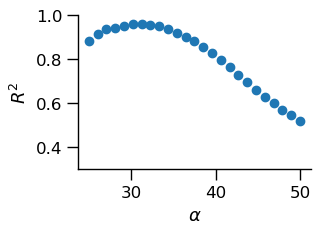

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(3, 2))
axes.scatter(data['alpha_values'], corr_mat.flatten())
axes.set_ylim(0.3, 1)
axes.set_ylabel(r'$R^2$')
axes.set_xlabel(r'$\alpha$')
format_plot(axes)